# ResNet18 on CIFAR-10

Train ResNet18 on CIFAR-10 dataset with 80/20 train/validation split.

## Model Definition

In [1]:
"""
ResNet18 model modified for CIFAR-10 dataset

Key modifications:
1. Replace 7x7 conv stride 2 with 3x3 conv stride 1
2. Remove max pooling layer
3. Change output layer to 10 classes (instead of 1000)
"""

import torch
import torch.nn as nn


class BasicBlock(nn.Module):
    """Basic residual block for ResNet18"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet18CIFAR(nn.Module):
    """ResNet18 modified for CIFAR-10 (32x32 input images)"""

    def __init__(self, num_classes=10):
        super(ResNet18CIFAR, self).__init__()
        self.in_channels = 64

        # Modified first conv layer for CIFAR-10
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # ResNet layers
        self.layer1 = self._make_layer(BasicBlock, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def test_model():
    model = ResNet18CIFAR(num_classes=10)
    x = torch.randn(2, 3, 32, 32)
    output = model(x)
    print(f"Input shape: {x.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


if __name__ == '__main__':
    test_model()

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 10])
Model parameters: 11,173,962


In [2]:
# Test model
test_model()

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 10])
Model parameters: 11,173,962


## Import Libraries

In [3]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.8.0+cu126
Device: cuda
GPU: Tesla T4


## Configuration

In [4]:
config = {
    'data_root': './data',
    'num_epochs': 30,
    'batch_size': 128,
    'learning_rate': 0.1,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'num_workers': 2,
    'train_split': 0.8,
    'save_dir': 'weights',
    'results_dir': 'results',
}

os.makedirs(config['save_dir'], exist_ok=True)
os.makedirs(config['results_dir'], exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"\nConfig: {config}")

Device: cuda

Config: {'data_root': './data', 'num_epochs': 30, 'batch_size': 128, 'learning_rate': 0.1, 'momentum': 0.9, 'weight_decay': 0.0005, 'num_workers': 2, 'train_split': 0.8, 'save_dir': 'weights', 'results_dir': 'results'}


## Load Dataset

In [5]:
# CIFAR-10 normalization
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

# Transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load dataset
full_train_dataset = datasets.CIFAR10(
    root=config['data_root'],
    train=True,
    download=True,
    transform=None
)

# Split
train_size = int(config['train_split'] * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

train_dataset = TransformedDataset(train_dataset, train_transform)
val_dataset = TransformedDataset(val_dataset, val_transform)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=torch.cuda.is_available()
)

print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print(f"Batches: {len(train_loader)} train, {len(val_loader)} val")

100%|██████████| 170M/170M [00:01<00:00, 104MB/s]


Train: 40,000 | Val: 10,000
Batches: 313 train, 79 val


## Training Functions

In [6]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'  [{epoch}] [{batch_idx+1}/{len(train_loader)}] '
                  f'Loss: {running_loss/(batch_idx+1):.4f} | '
                  f'Acc: {100.*correct/total:.2f}%')
    
    return running_loss / len(train_loader), 100. * correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(val_loader), 100. * correct / total

## Visualization

In [7]:
def save_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    ax1.plot(epochs, train_losses, 'b-', linewidth=2, marker='o', label='Train')
    ax1.plot(epochs, val_losses, 'r-', linewidth=2, marker='s', label='Val')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy
    ax2.plot(epochs, train_accs, 'b-', linewidth=2, marker='o', label='Train')
    ax2.plot(epochs, val_accs, 'r-', linewidth=2, marker='s', label='Val')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Initialize Model

In [8]:
model = ResNet18CIFAR(num_classes=10)
model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=config['learning_rate'],
    momentum=config['momentum'],
    weight_decay=config['weight_decay']
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 25],
    gamma=0.1
)

Parameters: 11,173,962


## Training

In [9]:
print(f"Training for {config['num_epochs']} epochs...\n")

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0
start_time = time.time()

for epoch in range(1, config['num_epochs'] + 1):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    epoch_time = time.time() - epoch_start
    
    print(f"\nEpoch {epoch}/{config['num_epochs']}:")
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    print(f"  Time: {epoch_time:.1f}s")
    print("-" * 60)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_path = os.path.join(config['save_dir'], 'resnet18_best.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved ({best_val_acc:.2f}%)")
    
    if epoch % 10 == 0:
        checkpoint = os.path.join(config['save_dir'], f'resnet18_epoch_{epoch}.pth')
        torch.save(model.state_dict(), checkpoint)
        print(f"  ✓ Checkpoint saved")

total_time = time.time() - start_time
print(f"\nTraining complete: {total_time/60:.1f} min")
print(f"Best val acc: {best_val_acc:.2f}%")

final_model_path = os.path.join(config['save_dir'], 'resnet18_final.pth')
torch.save(model.state_dict(), final_model_path)

Training for 30 epochs...

  [1] [100/313] Loss: 2.4781 | Acc: 19.52%
  [1] [200/313] Loss: 2.1625 | Acc: 25.05%
  [1] [300/313] Loss: 2.0020 | Acc: 29.11%

Epoch 1/30:
  Train: Loss=1.9858, Acc=29.49%
  Val:   Loss=1.5483, Acc=43.26%
  Time: 32.9s
------------------------------------------------------------
  ✓ Best model saved (43.26%)
  [2] [100/313] Loss: 1.5347 | Acc: 43.20%
  [2] [200/313] Loss: 1.4992 | Acc: 44.44%
  [2] [300/313] Loss: 1.4536 | Acc: 46.27%

Epoch 2/30:
  Train: Loss=1.4473, Acc=46.51%
  Val:   Loss=1.2960, Acc=53.27%
  Time: 32.7s
------------------------------------------------------------
  ✓ Best model saved (53.27%)
  [3] [100/313] Loss: 1.2529 | Acc: 54.62%
  [3] [200/313] Loss: 1.2175 | Acc: 56.07%
  [3] [300/313] Loss: 1.1814 | Acc: 57.65%

Epoch 3/30:
  Train: Loss=1.1774, Acc=57.79%
  Val:   Loss=1.0337, Acc=62.46%
  Time: 33.9s
------------------------------------------------------------
  ✓ Best model saved (62.46%)
  [4] [100/313] Loss: 1.0307 | Acc

## Results

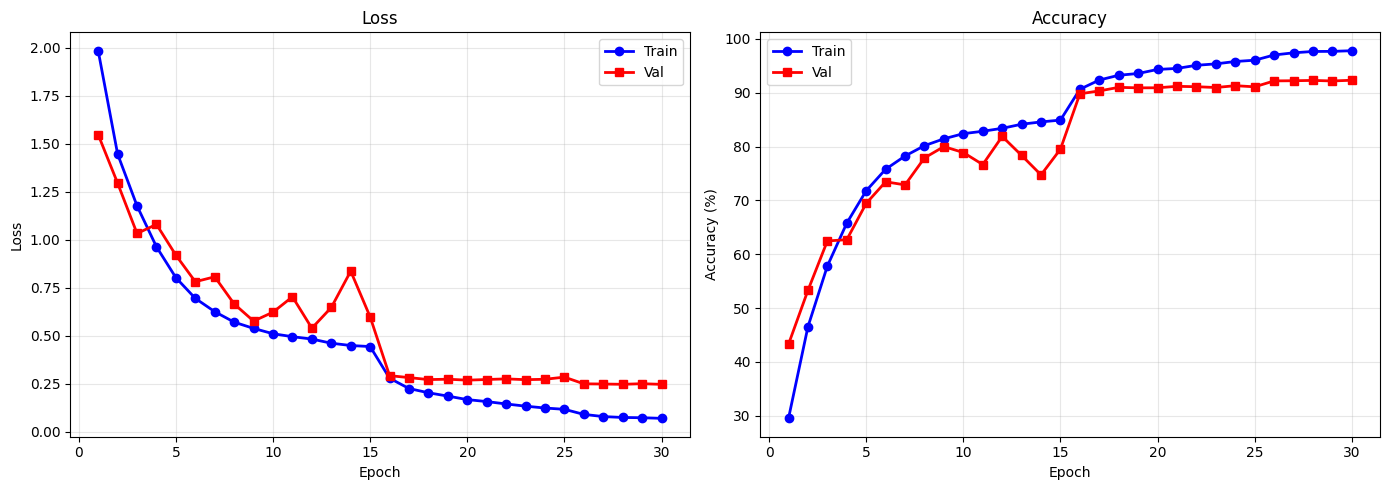


Final Results:
  Train Acc: 97.82%
  Val Acc:   92.33%
  Best Val:  92.33%


In [10]:
curves_path = os.path.join(config['results_dir'], 'resnet18_curves.png')
save_curves(train_losses, val_losses, train_accs, val_accs, curves_path)

print(f"\nFinal Results:")
print(f"  Train Acc: {train_accs[-1]:.2f}%")
print(f"  Val Acc:   {val_accs[-1]:.2f}%")
print(f"  Best Val:  {best_val_acc:.2f}%")

## Download (Kaggle)

In [11]:
import shutil

try:
    shutil.copy(best_model_path, '/kaggle/working/')
    shutil.copy(final_model_path, '/kaggle/working/')
    shutil.copy(curves_path, '/kaggle/working/')
    print("Files copied to /kaggle/working/")
except:
    print("Not in Kaggle environment")

Files copied to /kaggle/working/
